# Synthetic Data Generation

**Цель:** Генерация синтетических чертежей двумя способами:
1. **GOST генерация** — рисуем штамп по ГОСТ (185×55mm)
2. **Copy-paste** — копируем реальный штамп на другой чертёж

**Параметры:**
- Штамп: 185×55mm (FORM_3)
- DPI: 200
- Corner placement: random


In [1]:
import sys
sys.path.insert(0, '../src')

from pathlib import Path
import cv2
import matplotlib.pyplot as plt
import random

from data.loader import load_image_and_labels
from data.synthetic import (
    generate_synthetic_image,
    generate_synthetic_from_real,
    crop_stamp_from_image,
    GOST_FORMS
)

DATA_DIR = Path('../data')
IMAGE_DIR = DATA_DIR / 'images' / 'test'
LABEL_DIR = DATA_DIR / 'labels' / 'test'

print('OK')


OK


## Метод 1: GOST генерация

Генерируем штамп по ГОСТ (185×55mm) с сеткой и текстом.

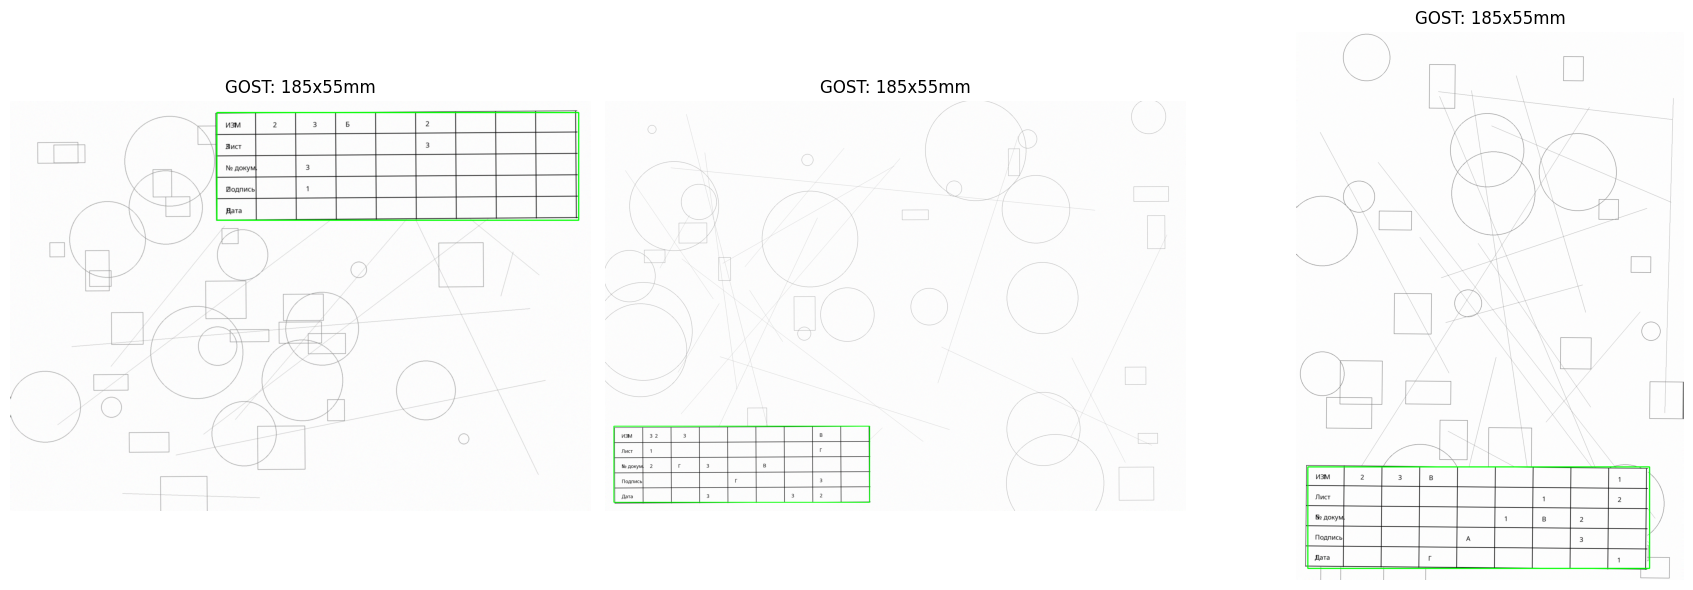

In [2]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for i, ax in enumerate(axes):
    img, label, meta = generate_synthetic_image(dpi=200)
    x, y, w, h = meta['stamp_bbox']
    cv2.rectangle(img, (x, y), (x+w, y+h), (0, 255, 0), 3)
    ax.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    ax.set_title(f"GOST: {meta['form_width_mm']}x{meta['form_height_mm']}mm")
    ax.axis('off')

plt.tight_layout()
plt.show()


## Метод 2: Copy-paste штампов

Копируем реальные штампы из размеченных изображений на другие чертежи.

In [3]:
# Загружаем реальные изображения и вырезаем штампы
all_images = sorted(IMAGE_DIR.glob('*.png')) + sorted(IMAGE_DIR.glob('*.jpg'))
real_stamps = []

for img_path in all_images:
    img, lbls = load_image_and_labels(img_path, LABEL_DIR)
    if lbls.size > 0:
        stamp = crop_stamp_from_image(img, lbls, margin=0.05)
        if stamp.size > 0:
            real_stamps.append((img_path, img, stamp))

print(f'Загружено штампов: {len(real_stamps)}')
if real_stamps:
    print(f'Пример штампа: {real_stamps[0][2].shape}')


Загружено штампов: 49
Пример штампа: (370, 1492, 3)


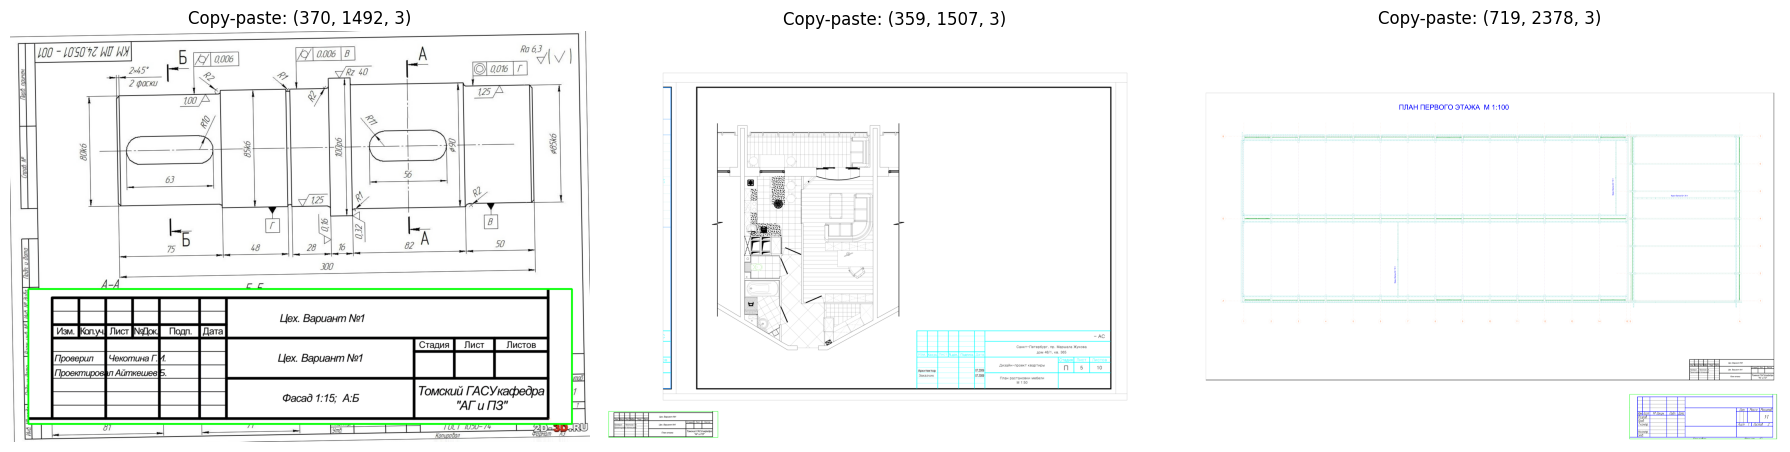

In [4]:
# Генерируем синтетику copy-paste
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for i, ax in enumerate(axes):
    # Случайный штамп
    _, bg_img, stamp = real_stamps[i % len(real_stamps)]
    
    # Случайный фон
    _, bg2, _ = random.choice(real_stamps)
    
    synth, label, meta = generate_synthetic_from_real(bg2, stamp)
    x, y, w, h = meta['stamp_bbox']
    cv2.rectangle(synth, (x, y), (x+w, y+h), (0, 255, 0), 3)
    ax.imshow(cv2.cvtColor(synth, cv2.COLOR_BGR2RGB))
    ax.set_title(f'Copy-paste: {stamp.shape}')
    ax.axis('off')

plt.tight_layout()
plt.show()


## Выводы

**Доступные методы:**
1. **GOST генерация** — синтетический штамп с сеткой
2. **Copy-paste** — реальные штампы на случайных фонах

**Применение:**
- GOST: гарантированные размеры 185×55mm
- Copy-paste: более реалистичные штампы

**Следующий шаг:** Обучение YOLO
